In [1]:
import pandas as pd


In [4]:
df_author = pd.read_csv("https://dlsun.github.io/pods/data/federalist/authorship.csv")
df_author.head()

,Paper,Author
0,1,Hamilton
1,2,Jay
2,3,Jay
3,4,Jay
4,5,Jay


**Question 0:**

Recall that 15 of the papers have disputed authorship. How could you use the topics we have covered so far and the papers with known authorship to “predict” the authors of the 15 disputed papers?

I would compare the writing style of the disputed papers to the papers with known authorship. I could use word frequencies to represent each paper and then use a distance measure, such as cosine distance, to find which known papers are most similar to each disputed paper and predict the author based on those similarities.

**Question 1:**


In [9]:
import requests

papers = []

for i in range(1, 86):
    url = f"https://dlsun.github.io/pods/data/federalist/{i}.txt"
    text = requests.get(url).text
    papers.append(text)

In [10]:
len(papers)

85

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=50)

tf_matrix = vectorizer.fit_transform(papers)

df_tf = pd.DataFrame(
    tf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_tf.shape

(85, 50)

In [12]:
df_tf["Paper"] = range(1, 86)

In [13]:
df_tf = df_tf.merge(
    df_author,
    on="Paper",
    how="left")

df_tf.head()

,all,an,and,any,are,as,at,be,been,but,...,this,those,to,we,which,will,with,would,Paper,Author
0,9,11,40,6,12,10,8,34,3,2,...,14,9,72,8,18,25,6,2,1,Hamilton
1,4,1,83,1,6,16,10,15,8,8,...,14,2,53,5,11,2,13,5,2,Jay
2,4,3,60,5,8,24,1,31,2,7,...,6,6,56,0,11,24,10,2,3,Jay
3,4,3,90,5,11,20,2,26,2,10,...,1,4,51,10,10,15,12,17,4,Jay
4,4,4,72,3,3,3,4,31,0,4,...,6,9,45,5,10,7,11,37,5,Jay


In [14]:
df_tf.shape

(85, 52)

In [ ]:
author_means = (
    df_tf
    .dropna(subset=["Author"])
    .groupby("Author")
    .mean(numeric_only=True))

author_means

,all,an,and,any,are,as,at,be,been,but,...,they,this,those,to,we,which,will,with,would,Paper
Author,,,,,,,,,,,,,,,,,,,,,
Hamilton,8.568627,12.470588,53.333333,7.196078,11.431373,19.019608,7.392157,45.098039,9.607843,7.921569,...,10.352941,18.078431,6.352941,90.156863,6.000000,24.411765,13.764706,12.000000,18.137255,45.607843
Jay,4.800000,3.400000,81.600000,4.400000,10.600000,20.400000,4.400000,32.000000,3.200000,8.200000,...,17.400000,7.600000,7.200000,58.600000,5.000000,11.200000,14.600000,12.000000,13.600000,15.600000
Madison,10.642857,11.785714,83.142857,5.785714,14.857143,26.571429,5.500000,53.857143,13.857143,10.142857,...,13.142857,17.785714,5.142857,90.071429,5.357143,30.285714,17.642857,15.142857,11.357143,38.142857


**Question 2:**

In [16]:
author_long = (
author_means
.drop(columns="Paper")
.reset_index()
.melt(id_vars="Author",
        var_name="word",
        value_name="average_frequency"))

In [17]:
top_words = (
    author_long
    .sort_values("average_frequency", ascending=False)
    .groupby("Author")
    .head(10)
)

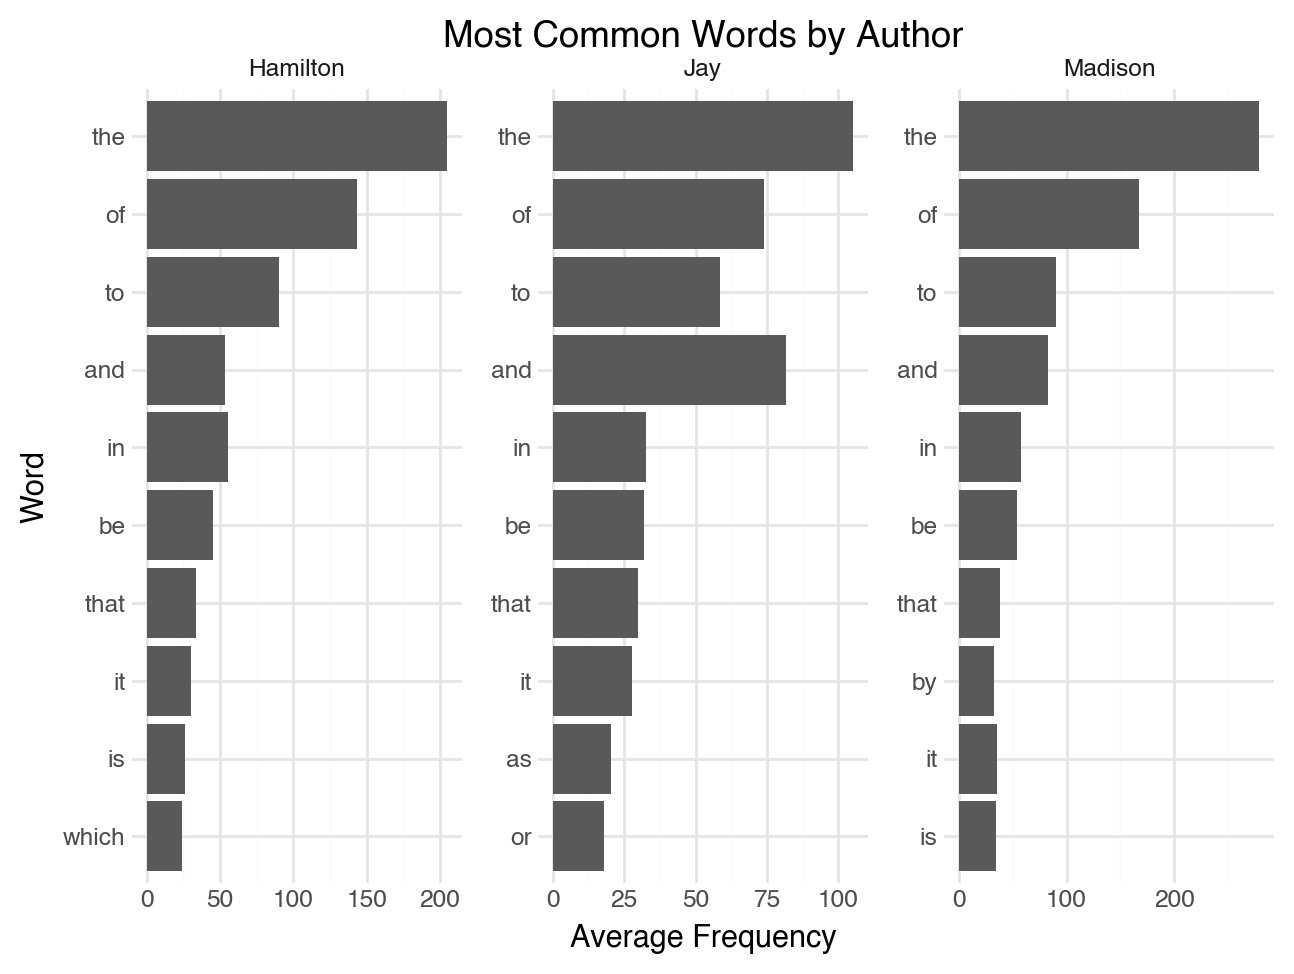

In [18]:
from plotnine import *

(ggplot(top_words,
    aes(x="reorder(word, average_frequency)",
        y="average_frequency"))
    + geom_col()
    + coord_flip()
    + facet_wrap("Author", scales="free")
    + labs(
        x="Word",
        y="Average Frequency",
        title="Most Common Words by Author")
    + theme_minimal())

The three authors use many of the same common words, especially “the,” “of,” and “to,” but they use them at different average frequencies. Madison appears to use some of these common words more often than Hamilton and Jay, while Jay shows a relatively high use of “and” compared with the others.

**Question 3:**

I would compare each disputed paper to the papers with known authorship using the term frequencies of the common words. I could calculate cosine distance to find the most similar known papers and then predict the author based on which author appears most often among the closest papers.

**Question 4:**

In [19]:
known = df_tf[df_tf["Author"].notna()].copy()
unknown = df_tf[df_tf["Author"].isna()].copy()

In [20]:
word_cols = vectorizer.get_feature_names_out()

In [21]:
from sklearn.metrics.pairwise import cosine_distances

In [22]:
predictions = []

for _, row in unknown.iterrows():
    distances = cosine_distances([row[word_cols]],
    known[word_cols])[0]

    temp = known[["Paper", "Author"]].copy()
    temp["distance"] = distances

    nearest5 = temp.sort_values("distance").head(5)

    predicted_author = nearest5["Author"].mode()[0]

    predictions.append({
        "Paper": row["Paper"],
        "Predicted_Author": predicted_author})

In [23]:
predicted_unknown = pd.DataFrame(predictions)

predicted_unknown

,Paper,Predicted_Author
0,18,Madison
1,19,Madison
2,20,Madison
3,49,Hamilton
4,50,Madison
5,51,Madison
6,52,Hamilton
7,53,Madison
8,54,Madison
9,55,Hamilton


In [24]:
predicted_unknown.groupby("Predicted_Author")["Paper"].apply(list)

Predicted_Author
Hamilton                        [49, 52, 55, 56, 62]
Madison     [18, 19, 20, 50, 51, 53, 54, 57, 58, 63]
Name: Paper, dtype: object

Using cosine distance and the five most similar papers with known authorship, I predicted papers 49, 52, 55, 56, and 62 were written by Hamilton. The remaining disputed papers were predicted to be written by Madison, and none were predicted to be written by Jay.

**Question 5:**

In [25]:
known_predictions = []

for _, row in known.iterrows():
    distances = cosine_distances([row[word_cols]],
        known[word_cols])[0]

    temp = known[["Paper", "Author"]].copy()
    temp["distance"] = distances

    # Remove the paper itself
    temp = temp[temp["Paper"] != row["Paper"]]

    nearest5 = temp.sort_values("distance").head(5)

    predicted_author = nearest5["Author"].mode()[0]

    known_predictions.append({
        "Paper": row["Paper"],
        "Actual_Author": row["Author"],
        "Predicted_Author": predicted_author})

results = pd.DataFrame(known_predictions)

results.head()

,Paper,Actual_Author,Predicted_Author
0,1,Hamilton,Hamilton
1,2,Jay,Madison
2,3,Jay,Jay
3,4,Jay,Jay
4,5,Jay,Jay


I used the same five nearest neighbors cosine distance method to predict the authors of papers with known authorship, excluding each paper from its own neighbor comparison.

**Question 6:**

In [27]:
results["correct"] = (
    results["Actual_Author"] == results["Predicted_Author"])

q6 = (results
    .groupby("Actual_Author")["correct"]
    .mean())
q6


Actual_Author
Hamilton    1.000000
Jay         0.600000
Madison     0.928571
Name: correct, dtype: float64

The algorithm correctly predicted 100% of Hamilton’s papers, 60% of Jay’s papers, and about 92.9% of Madison’s papers. This suggests the method works very well for Hamilton and Madison, but is less accurate for Jay.

**Question 7:**

In [28]:
q7 = (results
    .groupby("Predicted_Author")["correct"]
    .mean())

q7

Predicted_Author
Hamilton    0.980769
Jay         1.000000
Madison     0.866667
Name: correct, dtype: float64

Of the papers predicted to be written by Hamilton, about 98.1% were actually written by Hamilton. For Jay, 100% of the predicted papers were correct, while about 86.7% of the papers predicted to be Madison were actually written by Madison. Overall, the predictions were very accurate, especially for Hamilton and Jay.